#Day 5 Assignment: Smart Segmentation: Unlocking Customer Personas with AI

## Project Overview

In this project, we analyze customer data to discover meaningful patterns in spending behavior. The analysis focuses on understanding the relationship between **Gender** and **Spending Score**, and then applying **feature engineering and clustering techniques** to identify distinct customer segments.

By applying unsupervised machine learning methods such as **K-Means clustering**, we aim to uncover hidden customer personas that can help businesses design more targeted marketing strategies and improve customer engagement.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import scipy.cluster.hierarchy as sch

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

sns.set_style('whitegrid')

### Dataset Description

The dataset contains information about customers visiting a mall. Each record represents a customer with attributes related to demographics and spending behavior.

Key features in the dataset include:

- **CustomerID** – Unique identifier for each customer
- **Gender** – Male or Female
- **Age** – Age of the customer
- **Annual Income (k$)** – Annual income in thousands of dollars
- **Spending Score (1–100)** – Score assigned by the mall based on customer spending behavior

The goal of this project is to analyze spending patterns and identify groups of customers with similar behavior using clustering techniques.

In [2]:
!git clone "https://github.com/HarshvardhanSingh-13/Datasets"
df = pd.read_csv('/content/Datasets/Mall Dataset/Mall_Customers.csv')

print(f"Data shape: {df.shape}")
df.head()

Cloning into 'Datasets'...
remote: Enumerating objects: 347, done.
remote: Counting objects: 100% (105/105), done.
remote: Compressing objects: 100% (90/90), done.
remote: Total 347 (delta 25), reused 0 (delta 0), pack-reused 242 (from 1)
Receiving objects: 100% (347/347), 302.89 MiB | 18.42 MiB/s, done.
Resolving deltas: 100% (139/139), done.
Updating files: 100% (245/245), done.
Data shape: (200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
# Dataset shape
df.shape

(200, 5)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [5]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [6]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


## Gender Distribution

Understanding the distribution of male and female customers helps determine whether the dataset is balanced across genders.

This visualization shows how many customers belong to each gender category.

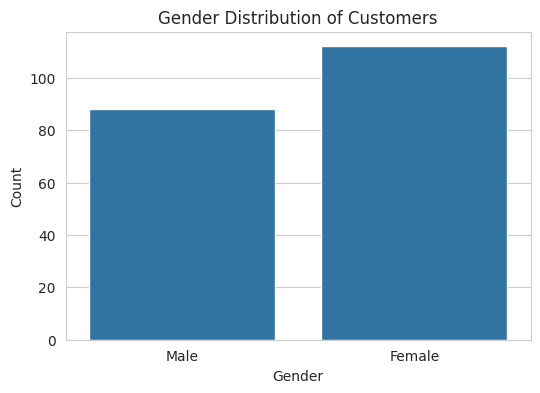

In [7]:
plt.figure(figsize=(6,4))

sns.countplot(x='Gender', data=df)

plt.title("Gender Distribution of Customers")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()


#### Observation

From the gender distribution plot, we observe that the dataset contains more female customers than male.

## Spending Score Distribution

The spending score represents how much a customer spends relative to others.

Visualizing its distribution helps us understand overall customer spending behavior.

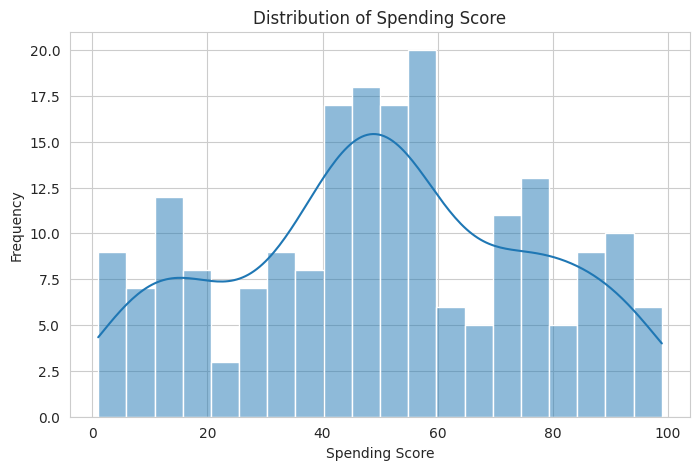

In [8]:
plt.figure(figsize=(8,5))

sns.histplot(df['Spending Score (1-100)'], bins=20, kde=True)

plt.title("Distribution of Spending Score")
plt.xlabel("Spending Score")
plt.ylabel("Frequency")

plt.show()

#### Observation

The spending score distribution shows that customer spending behavior is spread across the entire range from **1 to 100**.

Most customers appear to cluster around the **middle spending scores (around 40–60)**, indicating moderate spending behavior. However, there are also customers with very **low and very high spending scores**, suggesting the presence of different spending patterns among customers.

## Gender vs Spending Score Analysis

To understand whether gender influences spending behavior, we visualize the relationship between **Gender** and **Spending Score**.



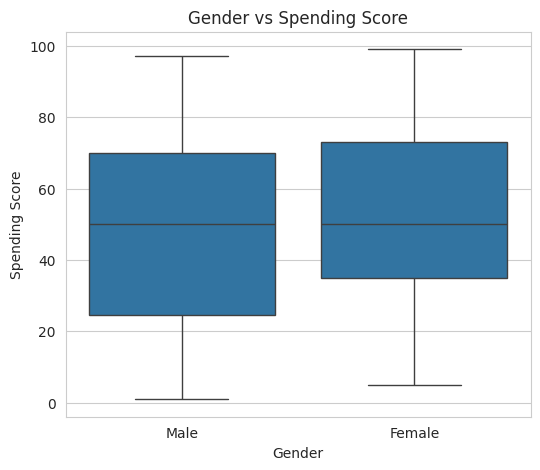

In [9]:
plt.figure(figsize=(6,5))

sns.boxplot(x='Gender', y='Spending Score (1-100)', data=df)

plt.title("Gender vs Spending Score")
plt.xlabel("Gender")
plt.ylabel("Spending Score")

plt.show()

### Observation

From the boxplot comparing **Gender and Spending Score**, we observe that both male and female customers have a similar distribution of spending scores.

**Female customers** appear to have a slightly wider spread and slightly higher upper spending scores compared to male customers. This suggests that female customers may include a higher proportion of high-spending individuals.


## Gender vs Spending Score Scatter Visualization


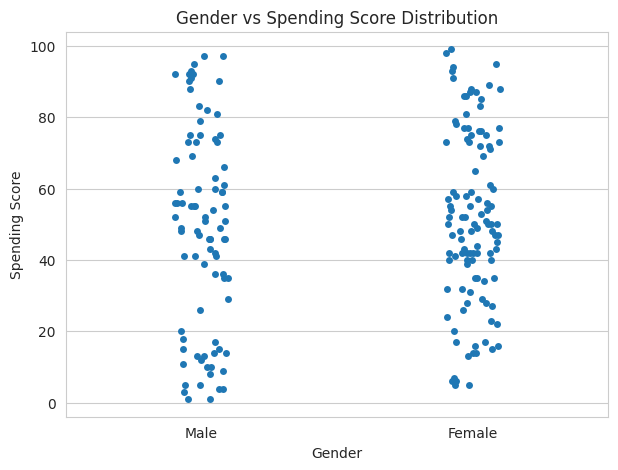

In [10]:
plt.figure(figsize=(7,5))

sns.stripplot(x='Gender', y='Spending Score (1-100)', data=df)

plt.title("Gender vs Spending Score Distribution")
plt.xlabel("Gender")
plt.ylabel("Spending Score")

plt.show()

#### Observation

The scatter plot shows individual spending scores for both male and female customers. Customers from both genders are distributed across the entire spending score range from low to high values.

This indicates that **both male and female customers exhibit diverse spending behaviors**, ranging from low spenders to high spenders.

## Spending Score Summary by Gender

To better understand spending behavior across genders, we compute the average spending score for each gender group.

In [11]:
df.groupby("Gender")["Spending Score (1-100)"].describe()

,count,mean,std,min,25%,50%,75%,max
Gender,,,,,,,,
Female,112.0,51.526786,24.11495,5.0,35.0,50.0,73.0,99.0
Male,88.0,48.511364,27.89677,1.0,24.5,50.0,70.0,97.0


#### Observation

From the summary statistics of spending score by gender, we observe that female customers have a slightly higher **average spending score (~51.5)** compared to male customers (~48.5).

The median spending score for both genders is around **50**, indicating that the central spending behavior is quite similar. However, female customers show a slightly higher upper range of spending scores.

Overall, this suggests that while spending behavior is broadly similar across genders, **female customers tend to have slightly higher spending on average**.

## Feature Engineering for Customer Segmentation

In this project, we create a new feature called **Income-to-Spending Ratio**, which compares a customer's annual income to their spending score. This feature may help reveal how efficiently customers convert income into spending behavior.



In [12]:
# Create new feature: Income-to-Spending Ratio

df["Income_Spending_Ratio"] = df["Annual Income (k$)"] / df["Spending Score (1-100)"]

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Income_Spending_Ratio
0,1,Male,19,15,39,0.384615
1,2,Male,21,15,81,0.185185
2,3,Female,20,16,6,2.666667
3,4,Female,23,16,77,0.207792
4,5,Female,31,17,40,0.425000


## Feature Selection for Clustering

For clustering, we select relevant features that represent customer characteristics and spending behavior.

The features chosen for clustering are:

- Annual Income
- Spending Score
- Income-Spending Ratio

In [13]:
# Select features for clustering

features = df[["Annual Income (k$)", "Spending Score (1-100)", "Income_Spending_Ratio"]]

features.head()

,Annual Income (k$),Spending Score (1-100),Income_Spending_Ratio
0,15,39,0.384615
1,15,81,0.185185
2,16,6,2.666667
3,16,77,0.207792
4,17,40,0.425000


##Feature Scaling

In [14]:
scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

## Determining Optimal Number of Clusters (Elbow Method)

Before applying K-Means clustering, we need to determine the optimal number of clusters (K).

The **Elbow Method** helps identify the best number of clusters by measuring the **Within-Cluster Sum of Squares (WCSS)** for different values of K.

The optimal value of K is typically found at the point where the rate of decrease in WCSS slows down significantly, forming an "elbow" in the graph.

In [15]:
# Calculate WCSS for different cluster values

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

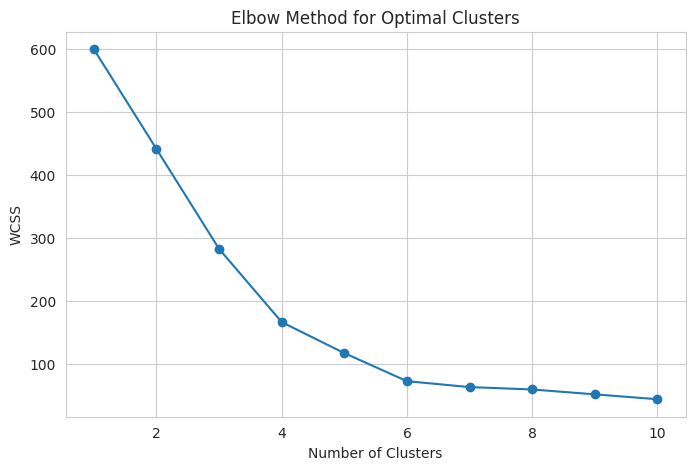

In [16]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title("Elbow Method for Optimal Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.show()

### Observation

From the Elbow Method plot, we observe that the WCSS (Within-Cluster Sum of Squares) decreases rapidly as the number of clusters increases from 1 to about 5. After **K = 5**, the rate of decrease becomes much slower and the curve begins to flatten.

This point forms the "elbow" in the graph, indicating that **5 is the optimal number of clusters** for this dataset.

## K-Means Clustering

In [17]:
# Apply K-Means clustering

kmeans = KMeans(n_clusters=5, random_state=42)

clusters = kmeans.fit_predict(scaled_features)

df["Cluster"] = clusters

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Income_Spending_Ratio,Cluster
0,1,Male,19,15,39,0.384615,0
1,2,Male,21,15,81,0.185185,2
2,3,Female,20,16,6,2.666667,0
3,4,Female,23,16,77,0.207792,2
4,5,Female,31,17,40,0.425000,0


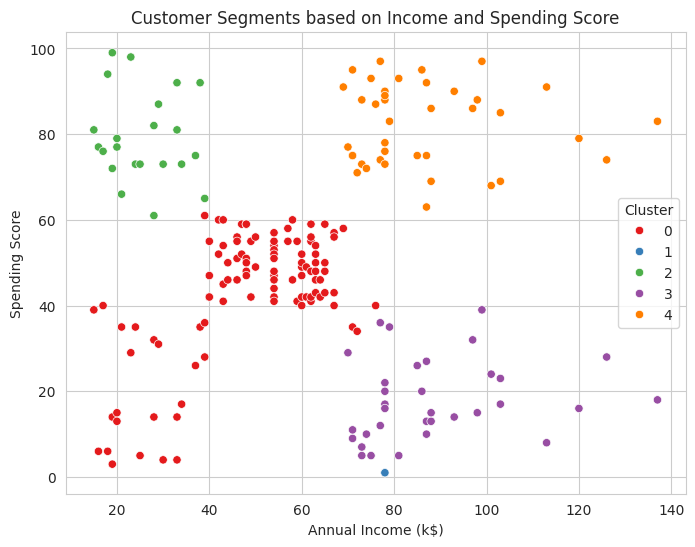

In [18]:
# Cluster Segmentation Visualization
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df["Annual Income (k$)"],
    y=df["Spending Score (1-100)"],
    hue=df["Cluster"],
    palette="Set1"
)

plt.title("Customer Segments based on Income and Spending Score")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")

plt.show()

#### Observation

The scatter plot shows five distinct customer segments formed based on **Annual Income** and **Spending Score**.

Some clusters represent customers with **high income and high spending scores**, indicating premium or loyal customers who contribute significantly to revenue. Other clusters include **high income but low spending customers**, who may be potential targets for marketing strategies to increase their engagement.

There are also clusters of **low income but high spending customers**, as well as **low income and low spending customers**, representing different purchasing behaviors.

## Cluster Distribution

To understand how customers are distributed across the clusters, we count the number of customers in each segment.

In [19]:
df["Cluster"].value_counts()

,count
Cluster,
0,104
4,39
3,33
2,22
1,2


### Observation

The cluster distribution shows that customers are unevenly distributed across the five clusters.

Cluster **0** contains the largest number of customers, suggesting that this spending pattern is the most common among the dataset. Clusters **3** and **4** contain a moderate number of customers, while clusters **2** and **1** contain relatively fewer customers.